<a href="https://colab.research.google.com/github/Colloh8/First-project/blob/main/financial_loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/financial_loan_data (1).csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [11]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [12]:
# Clean 'AnnualIncome' column
df['AnnualIncome'] = df['AnnualIncome'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['AnnualIncome'] = pd.to_numeric(df['AnnualIncome'])

# Impute missing values for categorical columns with mode
df['EducationLevel'] = df['EducationLevel'].fillna(df['EducationLevel'].mode()[0])
df['MaritalStatus'] = df['MaritalStatus'].fillna(df['MaritalStatus'].mode()[0])

# Impute missing values for numerical columns with median
df['SavingsAccountBalance'] = df['SavingsAccountBalance'].fillna(df['SavingsAccountBalance'].median())

# Verify the changes
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  float64
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              20000 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               20000 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [13]:
# Identify categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first 5 rows of the DataFrame after encoding
display(df.head())

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MaritalStatus_Single,MaritalStatus_Widowed,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,BankruptcyHistory_Yes,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,45,39948.0,617,22,13152,48,2,183,0.354418,1,...,False,False,False,True,False,False,False,False,True,False
1,38,39709.0,628,15,26045,48,1,496,0.087827,5,...,True,False,False,False,False,False,True,False,False,False
2,47,40724.0,570,26,17627,36,2,902,0.137414,2,...,False,False,False,False,True,False,False,True,False,False
3,58,69084.0,545,34,37898,96,1,755,0.267587,2,...,True,False,False,False,False,False,False,False,True,False
4,37,103264.0,594,17,9184,36,1,274,0.320535,0,...,False,False,False,False,False,False,True,False,False,False


In [14]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop(['LoanApproved', 'RiskScore'], axis=1) # Drop RiskScore as it's a potential target for regression, but not for classification and is derived
y = df['LoanApproved']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16000, 44)
X_test shape: (4000, 44)
y_train shape: (16000,)
y_test shape: (4000,)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      3044
           1       0.84      0.78      0.81       956

    accuracy                           0.91      4000
   macro avg       0.89      0.87      0.88      4000
weighted avg       0.91      0.91      0.91      4000



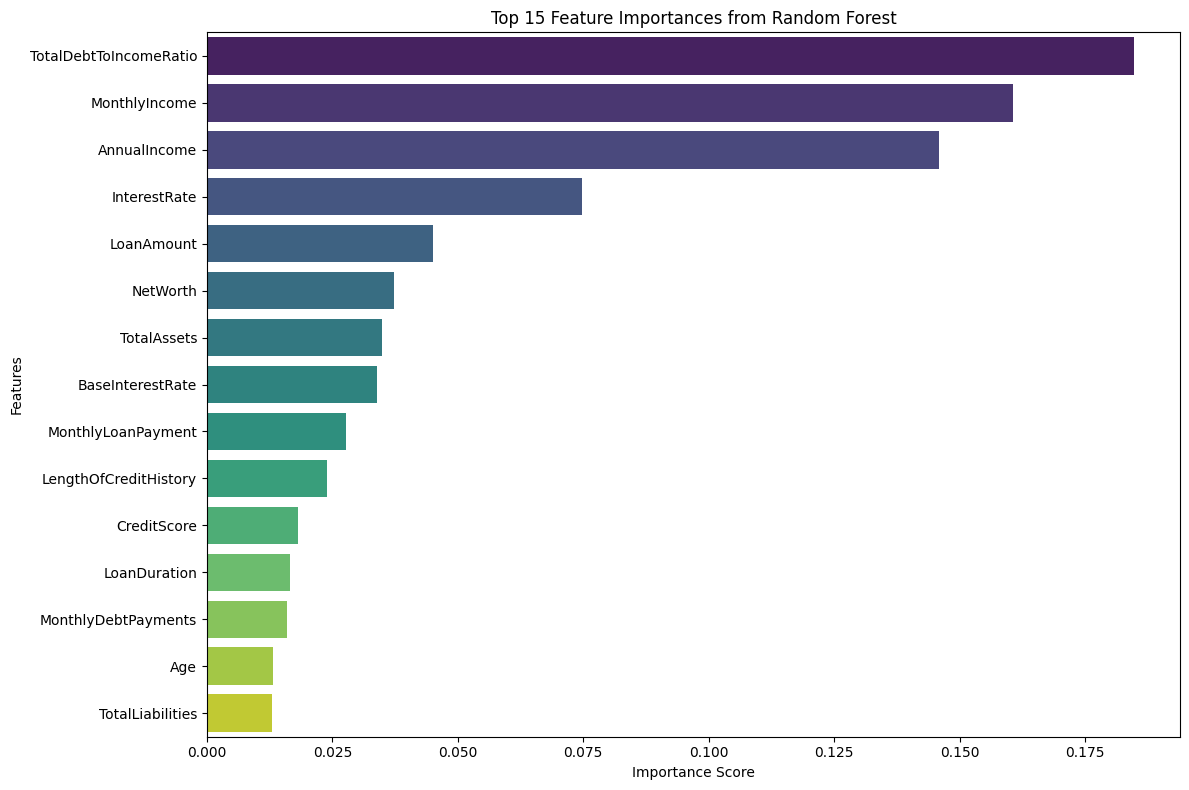

In [16]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train a RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort feature importances and select the top 15
top_features = feature_importances.nlargest(15)

# Create a bar plot of feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', hue=top_features.index, legend=False)
plt.title('Top 15 Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Addressing Class Imbalance with SMOTE

Given the imbalance in our target variable (`LoanApproved`), where approved loans (Class 1) are significantly fewer than denied loans (Class 0), we will use the Synthetic Minority Over-sampling Technique (SMOTE) to balance the training dataset. This technique generates synthetic samples for the minority class, helping the model learn more effectively from both classes.

In [17]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training set shape: {y_train.shape}")
print(f"Resampled training set shape: {y_train_resampled.shape}")
print(f"Class distribution after SMOTE:\n{y_train_resampled.value_counts()}")

Original training set shape: (16000,)
Resampled training set shape: (24352,)
Class distribution after SMOTE:
LoanApproved
0    12176
1    12176
Name: count, dtype: int64


With the training data now balanced, we can retrain our Logistic Regression model (or other models) on this resampled data and evaluate its performance, particularly focusing on the metrics for the minority class (approved loans).